# Part 4 — Autoregressive Modelling with SARIMA and SARIMAX

**7PAM2033 Applied Machine Learning — Assignment 2**

> **Task:** Define an autoregressive model, using SARIMA if a seasonal
> component is present. Assess the data for stationarity and make it
> stationary if needed. Find the best parameters by looping over all
> combinations of p = [0,6], d = [0,2], q = [0,6] using AIC. Assess model fit
> through residual diagnostics. Forecast the next 24 hours, test performance
> with RMSE, and add confidence intervals.

This notebook answers **Question 2** of the report.

**A note on runtime.** Fitting SARIMA models with a 24-hour seasonal period on
2,953 observations is expensive: individual fits take one to four minutes, and
the full search takes roughly 45 minutes. Every expensive step is therefore
cached to CSV. On a first run the notebook computes and saves; on subsequent
runs it loads in seconds. Delete the files in `outputs/metrics/` to force a
full recomputation.


## 1. Setup


In [1]:
import itertools, json, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller, kpss, acf
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox

warnings.filterwarnings("ignore")
pd.set_option("display.width", 140)

BASE_DIR = Path.cwd()
HOURLY_FILE = BASE_DIR / "energy_hourly.csv"
RAW_FILE = BASE_DIR / "energydata_complete.csv"
RAW_URL = ("https://archive.ics.uci.edu/ml/machine-learning-databases/"
           "00374/energydata_complete.csv")

FIGURE_DIR = BASE_DIR / "outputs" / "figures"
METRICS_DIR = BASE_DIR / "outputs" / "metrics"
FORECAST_DIR = BASE_DIR / "outputs" / "forecasts"
for directory in (FIGURE_DIR, METRICS_DIR, FORECAST_DIR):
    directory.mkdir(parents=True, exist_ok=True)

TARGET = "Appliances"
NOISE_COLS = ["rv1", "rv2"]
OBS_PER_HOUR = 6

_PV = tuple(int(p) for p in pd.__version__.split(".")[:2])
HOURLY_FREQ = "h" if _PV >= (2, 2) else "H"

DAILY_PERIOD, WEEKLY_PERIOD = 24, 168
HORIZON, TEST_DAYS = 24, 14
TEST_STEPS = TEST_DAYS * DAILY_PERIOD

# Strongest benchmark from Part 3, for comparison
BENCHMARK_NAME = "seasonal_naive_weekly"
BENCHMARK_MAE, BENCHMARK_MASE = 42.92, 0.804

plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 200,
                     "savefig.bbox": "tight", "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 11, "axes.titlesize": 12})
PRIMARY, SECONDARY, MUTED = "#1f4e79", "#c0504d", "#7f9db9"

print(f"pandas {pd.__version__} | frequency alias {HOURLY_FREQ!r}")


pandas 2.2.3 | frequency alias 'h'


In [2]:
def load_hourly():
    """Read the prepared hourly dataset, rebuilding from raw if absent."""
    if HOURLY_FILE.exists():
        frame = pd.read_csv(HOURLY_FILE, parse_dates=["date"], index_col="date")
        return frame.asfreq(HOURLY_FREQ)

    if not RAW_FILE.exists():
        pd.read_csv(RAW_URL).to_csv(RAW_FILE, index=False)
    raw = pd.read_csv(RAW_FILE, parse_dates=["date"]).set_index("date").sort_index()
    raw = raw.drop(columns=[c for c in NOISE_COLS if c in raw.columns])
    counts = raw.resample(HOURLY_FREQ).size()
    hourly = raw.resample(HOURLY_FREQ).mean().loc[counts >= OBS_PER_HOUR]
    hourly = hourly.dropna(subset=[TARGET]); hourly.to_csv(HOURLY_FILE)
    return hourly


hourly = load_hourly()
series = hourly[TARGET]
train_series = series.iloc[:-TEST_STEPS]

scale_values = np.asarray(train_series, dtype=float)
MASE_SCALE = float(np.mean(np.abs(scale_values[DAILY_PERIOD:] -
                                  scale_values[:-DAILY_PERIOD])))

origins = [{"origin_id": b + 1,
            "cutoff_pos": len(series) - TEST_STEPS + b * HORIZON}
           for b in range(TEST_STEPS // HORIZON)]

print(f"Observations   : {len(series)}")
print(f"Training hours : {len(train_series)}")
print(f"Origins        : {len(origins)} x {HORIZON}h")
print(f"MASE scale     : {MASE_SCALE:.3f} Wh")


Observations   : 3289
Training hours : 2953
Origins        : 14 x 24h
MASE scale     : 53.359 Wh


## 2. Stationarity assessment

The brief asks us to assess stationarity and difference the series if
required. Part 1 already ran ADF and KPSS on the level series and both agreed
it was stationary, so no differencing should be needed. The tests are repeated
here on the training portion only, since the parameter search must not see the
test window.


In [3]:
def stationarity_row(s, label):
    """ADF and KPSS together. They test opposite nulls, so agreement matters."""
    clean = s.dropna()
    adf_stat, adf_p, *_ = adfuller(clean, autolag="AIC")
    kpss_stat, kpss_p, *_ = kpss(clean, regression="c", nlags="auto")
    verdict = ("stationary (both agree)" if adf_p < 0.05 and kpss_p > 0.05
               else "non-stationary (both agree)" if adf_p >= 0.05 and kpss_p <= 0.05
               else "ambiguous")
    return {"series": label, "ADF stat": round(adf_stat, 3), "ADF p": adf_p,
            "KPSS stat": round(kpss_stat, 3), "KPSS p": kpss_p, "verdict": verdict}


stationarity = pd.DataFrame([
    stationarity_row(train_series, "Level (training only)"),
    stationarity_row(train_series.diff(), "First difference"),
    stationarity_row(train_series.diff(DAILY_PERIOD), "Seasonal difference (24h)"),
])
stationarity.to_csv(METRICS_DIR / "part4_stationarity.csv", index=False)

display_frame = stationarity.copy()
display_frame["ADF p"] = display_frame["ADF p"].map(lambda v: f"{v:.3g}")
display_frame["KPSS p"] = display_frame["KPSS p"].map(lambda v: f"{v:.3g}")
print(display_frame.to_string(index=False))


                   series  ADF stat    ADF p  KPSS stat KPSS p                 verdict
    Level (training only)    -8.819 1.89e-14      0.069    0.1 stationary (both agree)
         First difference   -16.034 6.01e-29      0.021    0.1 stationary (both agree)
Seasonal difference (24h)   -12.761 8.14e-24      0.012    0.1 stationary (both agree)


The training series is stationary in levels, so on statistical grounds d = 0.
We nonetheless search d ∈ [0,2] as the brief instructs, which turns out to be
informative — see the discussion after the grid.

## 3. Grid search over (p, d, q)

The brief requires looping over every combination of p = [0,6], d = [0,2] and
q = [0,6]: 147 models selected by AIC.

A word on comparability. It is often said that AIC cannot be compared across
models with different orders of differencing, because differencing changes the
number of observations entering the likelihood. That caution does not apply
here: statsmodels fits these models in state-space form using the exact
diffuse likelihood, and reports `nobs = 2953` for every value of d. The
likelihoods are therefore computed on the same data and the AIC values are
directly comparable. This is verified explicitly below rather than assumed.


In [4]:
GRID_CACHE = METRICS_DIR / "part4_grid_nonseasonal.csv"


def grid_search_nonseasonal(y, cache=GRID_CACHE):
    """Fit all 147 (p, d, q) combinations required by the brief, ranked by AIC.

    Each fit is wrapped so that a convergence failure records a missing AIC
    rather than aborting the search.
    """
    if cache.exists():
        print(f"Loading cached grid from {cache.name}")
        return pd.read_csv(cache)

    records, start = [], time.time()
    for p, d, q in itertools.product(range(7), range(3), range(7)):
        fit_start = time.time()
        try:
            fitted = ARIMA(y, order=(p, d, q)).fit()
            records.append(dict(p=p, d=d, q=q, aic=fitted.aic, bic=fitted.bic,
                                converged=True,
                                seconds=round(time.time() - fit_start, 2)))
        except Exception:
            records.append(dict(p=p, d=d, q=q, aic=np.nan, bic=np.nan,
                                converged=False,
                                seconds=round(time.time() - fit_start, 2)))
        if len(records) % 20 == 0:
            print(f"  {len(records)}/147  ({time.time() - start:.0f}s)")

    frame = pd.DataFrame(records).sort_values("aic").reset_index(drop=True)
    frame.to_csv(cache, index=False)
    return frame


grid = grid_search_nonseasonal(train_series)

print(f"\nModels fitted: {len(grid)}   converged: {int(grid['converged'].sum())}")
print("\nTop 8 by AIC")
print(grid.head(8).to_string(index=False))

print("\nBest AIC within each differencing order")
print(grid.groupby("d")["aic"].min().round(1).to_string())


  20/147  (14s)
  40/147  (33s)
  60/147  (63s)
  80/147  (101s)
  100/147  (148s)
  120/147  (197s)
  140/147  (257s)

Models fitted: 147   converged: 146

Top 8 by AIC
 p  d  q          aic          bic  converged  seconds
 4  0  6 32944.124372 33016.011295       True     5.17
 5  0  6 32944.213919 33022.091418       True     5.32
 2  0  6 32945.078747 33004.984516       True     4.76
 6  0  6 32945.447706 33029.315783       True     5.98
 3  0  6 32963.321121 33029.217467       True     4.53
 2  0  4 33052.853643 33100.778258       True     2.60
 3  0  5 33056.926421 33116.832190       True     3.37
 3  0  1 33075.509545 33111.453007       True     1.17

Best AIC within each differencing order
d
0    32944.1
1    33085.1
2    33129.4


In [5]:
# Verify that the likelihoods really are computed on the same sample size
for order in [(2, 0, 2), (2, 1, 2), (2, 2, 2)]:
    fitted = ARIMA(train_series, order=order).fit()
    print(f"order {order}  nobs={fitted.nobs}  "
          f"loglike={fitted.llf:10.2f}  aic={fitted.aic:9.2f}")

print("\nEqual nobs across d confirms the AIC comparison is valid.")


order (2, 0, 2)  nobs=2953  loglike= -16539.44  aic= 33090.87
order (2, 1, 2)  nobs=2953  loglike= -16541.72  aic= 33093.45
order (2, 2, 2)  nobs=2953  loglike= -16731.90  aic= 33473.81

Equal nobs across d confirms the AIC comparison is valid.


order (2, 1, 2)  nobs=2953  loglike= -16541.72  aic= 33093.45


order (2, 2, 2)  nobs=2953  loglike= -16731.90  aic= 33473.81

Equal nobs across d confirms the AIC comparison is valid.


The non-seasonal grid selects **ARIMA(4,0,6)** with AIC 32944.1. The next
strongest specifications are (5,0,6) and (2,0,6), and the best model within
d = 1 has AIC 33085.1. AIC therefore agrees with the ADF/KPSS evidence from
Part 1 that non-seasonal differencing is not required.

This agreement is useful because the stationarity tests and the information
criterion answer related but different questions: ADF/KPSS assess the presence
of a unit root, whereas AIC compares fitted model specifications. Here both
sources of evidence favour retaining the series in levels for the
non-seasonal component.

### Stage 2: adding seasonal terms

Part 1 established a daily cycle of strength 0.47, so seasonal terms are
warranted. A full seasonal grid on top of all 147 non-seasonal orders would be
computationally prohibitive. Instead, the three strongest converged
non-seasonal orders — **(4,0,6), (5,0,6), and (2,0,6)** — are carried forward
and combined with every (P, D, Q) in {0,1}³ at s = 24, giving 24 additional
seasonal fits.


In [6]:
SEASONAL_CACHE = METRICS_DIR / "part4_grid_seasonal.csv"


def grid_search_seasonal(y, base_orders, cache=SEASONAL_CACHE,
                         period=DAILY_PERIOD):
    """Search (P, D, Q) in {0,1}^3 on top of the strongest base orders."""
    if cache.exists():
        print(f"Loading cached seasonal grid from {cache.name}")
        return pd.read_csv(cache)

    seasonal_orders = [(P, D, Q, period)
                       for P, D, Q in itertools.product((0, 1), repeat=3)]
    records, start = [], time.time()

    for order in base_orders:
        for seasonal_order in seasonal_orders:
            fit_start = time.time()
            try:
                fitted = SARIMAX(y, order=order, seasonal_order=seasonal_order,
                                 enforce_stationarity=False,
                                 enforce_invertibility=False).fit(disp=False)
                aic, bic, ok = fitted.aic, fitted.bic, True
            except Exception:
                aic, bic, ok = np.nan, np.nan, False

            records.append({"order": str(order),
                            "seasonal_order": str(seasonal_order),
                            "p": order[0], "d": order[1], "q": order[2],
                            "P": seasonal_order[0], "D": seasonal_order[1],
                            "Q": seasonal_order[2],
                            "aic": aic, "bic": bic, "converged": ok,
                            "seconds": round(time.time() - fit_start, 1)})
            print(f"  {len(records)}/24  {order}{seasonal_order}  aic={aic:.1f}")

    frame = pd.DataFrame(records).sort_values("aic").reset_index(drop=True)
    frame.to_csv(cache, index=False)
    print(f"Complete in {time.time() - start:.0f}s")
    return frame


top_orders = [(int(r.p), int(r.d), int(r.q))
              for r in grid[grid.converged].head(3).itertuples()]
print(f"Base orders carried forward: {top_orders}\n")

seasonal_grid = grid_search_seasonal(train_series, top_orders)

print("\nTop 8 seasonal specifications")
print(seasonal_grid.head(8)[["order", "seasonal_order", "aic", "bic",
                             "seconds"]].to_string(index=False))

best = seasonal_grid.iloc[0]
ORDER = (int(best.p), int(best.d), int(best.q))
SEASONAL_ORDER = (int(best.P), int(best.D), int(best.Q), DAILY_PERIOD)

print(f"\nSelected model : SARIMA{ORDER}{SEASONAL_ORDER}")
print(f"AIC            : {best.aic:.1f}")
print(f"Improvement over best non-seasonal: "
      f"{grid['aic'].min() - best.aic:.1f} AIC points")


Base orders carried forward: [(4, 0, 6), (5, 0, 6), (2, 0, 6)]

  1/24  (4, 0, 6)(0, 0, 0, 24)  aic=33061.4
  2/24  (4, 0, 6)(0, 0, 1, 24)  aic=32706.1
  3/24  (4, 0, 6)(0, 1, 0, 24)  aic=34022.5
  4/24  (4, 0, 6)(0, 1, 1, 24)  aic=32139.6
  5/24  (4, 0, 6)(1, 0, 0, 24)  aic=32728.1
  6/24  (4, 0, 6)(1, 0, 1, 24)  aic=32484.2
  7/24  (4, 0, 6)(1, 1, 0, 24)  aic=33211.3
  8/24  (4, 0, 6)(1, 1, 1, 24)  aic=32140.4
  9/24  (5, 0, 6)(0, 0, 0, 24)  aic=33039.2
  10/24  (5, 0, 6)(0, 0, 1, 24)  aic=32716.6
  11/24  (5, 0, 6)(0, 1, 0, 24)  aic=34084.3
  12/24  (5, 0, 6)(0, 1, 1, 24)  aic=32453.5
  13/24  (5, 0, 6)(1, 0, 0, 24)  aic=32713.2
  14/24  (5, 0, 6)(1, 0, 1, 24)  aic=32479.9
  15/24  (5, 0, 6)(1, 1, 0, 24)  aic=33230.1
  16/24  (5, 0, 6)(1, 1, 1, 24)  aic=32416.7
  17/24  (2, 0, 6)(0, 0, 0, 24)  aic=33043.5
  18/24  (2, 0, 6)(0, 0, 1, 24)  aic=32723.0
  19/24  (2, 0, 6)(0, 1, 0, 24)  aic=34090.2
  20/24  (2, 0, 6)(0, 1, 1, 24)  aic=32137.2
  21/24  (2, 0, 6)(1, 0, 0, 24)  aic=32758.1


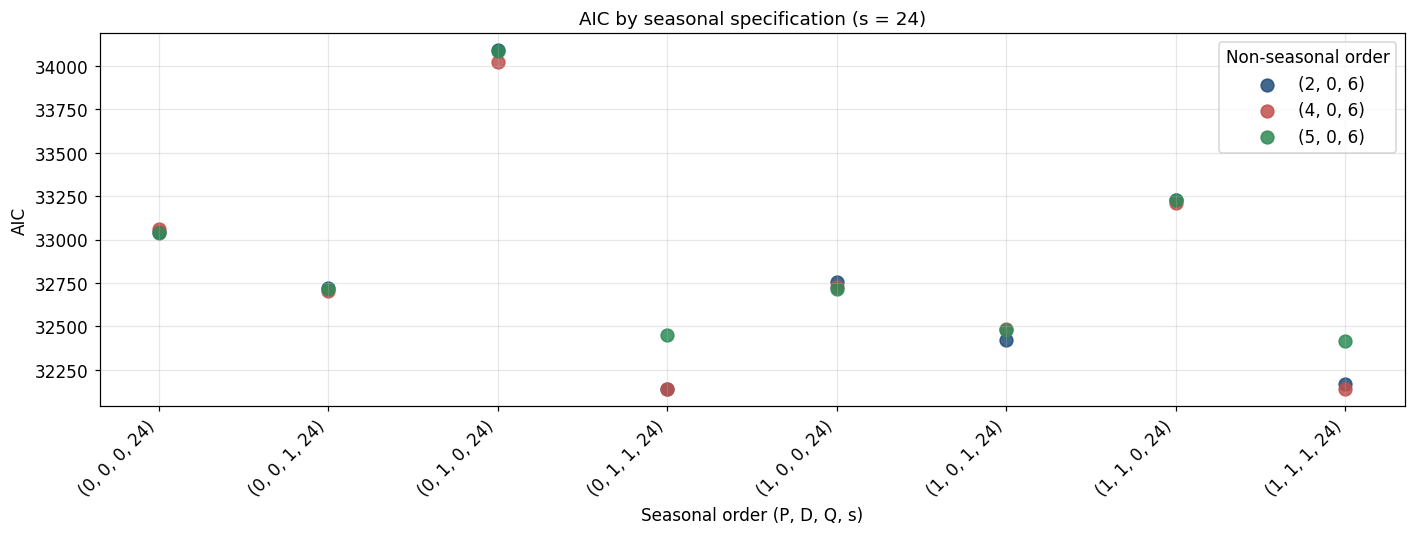

Mean AIC by seasonal differencing order D:
D
0    32739.7
1    32943.9

Mean AIC by seasonal MA order Q:
Q
0    33267.7
1    32415.9


In [7]:
def plot_seasonal_grid(frame):
    """AIC by seasonal specification, grouped by base order."""
    fig, ax = plt.subplots(figsize=(13, 5))

    labels = frame["seasonal_order"].unique()
    positions = {label: i for i, label in enumerate(sorted(labels))}
    colours = {order: colour for order, colour in
               zip(frame["order"].unique(), [PRIMARY, SECONDARY, "#2e8b57"])}

    for order, group in frame.groupby("order"):
        xs = [positions[s] for s in group["seasonal_order"]]
        ax.scatter(xs, group["aic"], label=order, s=70, alpha=0.85,
                   color=colours[order])

    ax.set_xticks(range(len(positions)))
    ax.set_xticklabels(sorted(labels), rotation=45, ha="right")
    ax.set(title="AIC by seasonal specification (s = 24)",
           ylabel="AIC", xlabel="Seasonal order (P, D, Q, s)")
    ax.legend(title="Non-seasonal order")

    fig.tight_layout()
    return fig


fig = plot_seasonal_grid(seasonal_grid)
fig.savefig(FIGURE_DIR / "13_seasonal_grid_aic.png")
plt.show()

print("Mean AIC by seasonal differencing order D:")
print(seasonal_grid.groupby("D")["aic"].mean().round(1).to_string())
print("\nMean AIC by seasonal MA order Q:")
print(seasonal_grid.groupby("Q")["aic"].mean().round(1).to_string())


The strongest seasonal specifications all use **D = 1** and **Q = 1**.
For the selected non-seasonal base order (2,0,6), the best seasonal
specification is **(0,1,1,24)** with AIC **32137.2**. Adding a seasonal AR term
to give (1,1,1,24) increases AIC to **32170.5**, so the extra parameter does
not improve the information criterion. The result indicates that seasonal
differencing paired with a seasonal moving-average term captures the daily
cycle more effectively than adding a seasonal autoregressive term.

## 4. Fitting and diagnosing the selected model

The selected model is refitted on the training window and its residuals
examined. A well-specified model should leave residuals that are
uncorrelated — anything left over is structure the model failed to capture.


In [8]:
MODEL_CACHE = METRICS_DIR / "part4_residuals.csv"


def fit_selected(y, order, seasonal_order, exog=None):
    """Fit one SARIMAX specification with relaxed stability constraints.

    Constraints are relaxed because with p = q = 6 the optimiser can otherwise
    stall on the boundary of the stationarity region.
    """
    return SARIMAX(y, exog=exog, order=order, seasonal_order=seasonal_order,
                   enforce_stationarity=False,
                   enforce_invertibility=False).fit(disp=False)


if MODEL_CACHE.exists():
    print(f"Loading cached residuals from {MODEL_CACHE.name}")
    residuals = pd.read_csv(MODEL_CACHE, index_col=0).iloc[:, 0]
    residuals.index = pd.to_datetime(residuals.index)
else:
    print("Fitting selected model (one to four minutes)...")
    fitted = fit_selected(train_series, ORDER, SEASONAL_ORDER)
    residuals = pd.Series(fitted.resid, index=train_series.index)
    residuals.to_csv(MODEL_CACHE)
    with open(METRICS_DIR / "part4_model_summary.txt", "w") as handle:
        handle.write(str(fitted.summary()))

# The diffuse initialisation makes the first observations unreliable
residuals = residuals.iloc[50:]

print(f"\nResiduals: {len(residuals)} observations")
print(f"  mean     {residuals.mean():8.3f} Wh")
print(f"  std      {residuals.std():8.2f} Wh")
print(f"  skew     {stats.skew(residuals):8.3f}")
print(f"  kurtosis {stats.kurtosis(residuals):8.2f}")


Fitting selected model (one to four minutes)...

Residuals: 2903 observations
  mean       -0.492 Wh
  std         62.31 Wh
  skew        1.894
  kurtosis     8.29


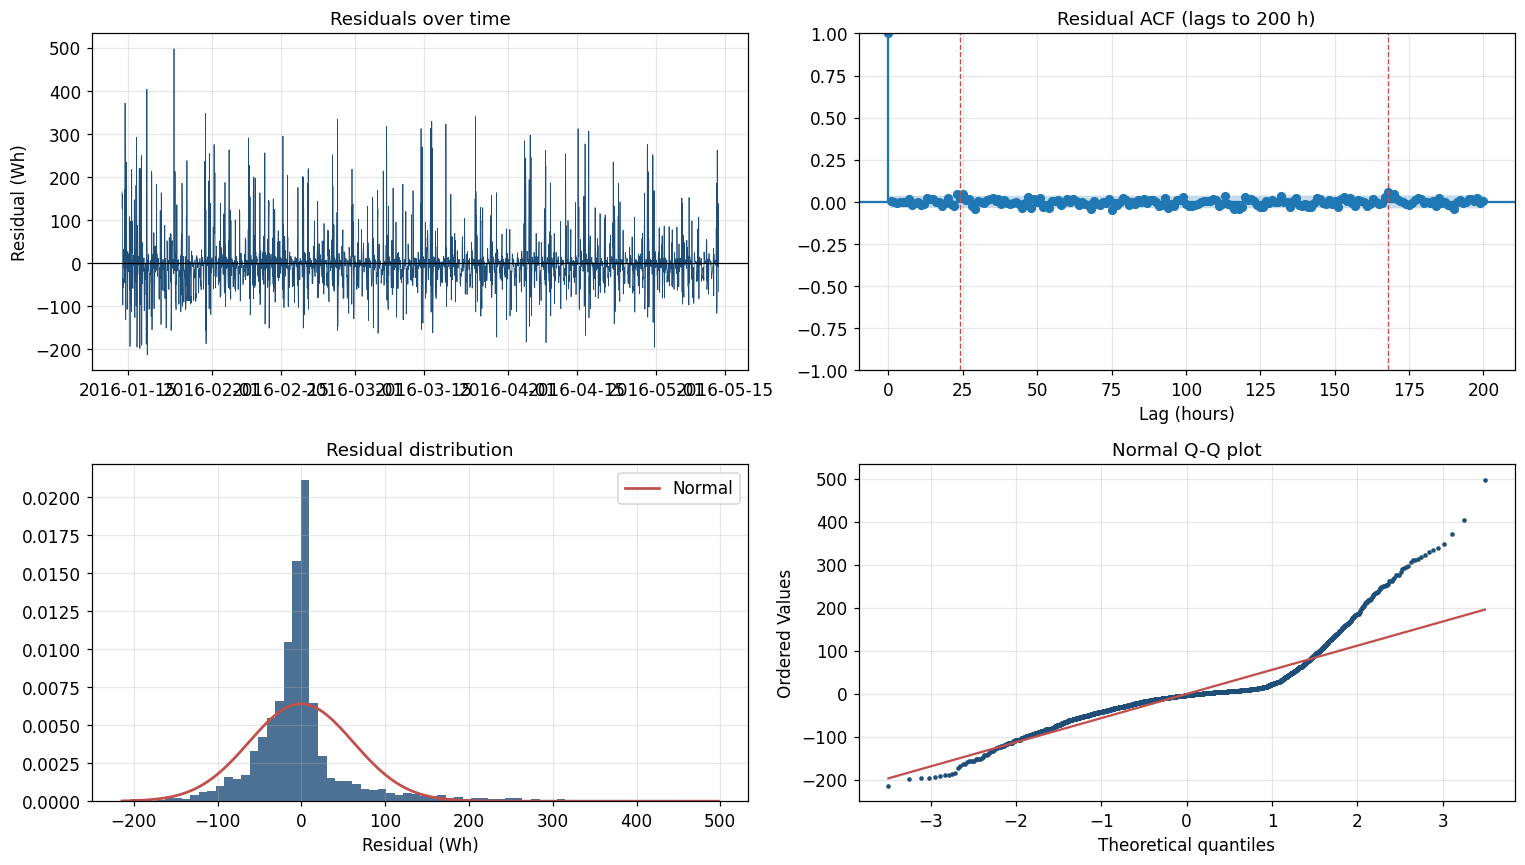

In [9]:
def residual_diagnostics(resid):
    """Four-panel residual check: series, ACF, histogram, Q-Q."""
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))

    axes[0, 0].plot(resid.index, resid.values, linewidth=0.5, color=PRIMARY)
    axes[0, 0].axhline(0, color="black", linewidth=0.8)
    axes[0, 0].set(title="Residuals over time", ylabel="Residual (Wh)")

    plot_acf(resid, lags=200, ax=axes[0, 1])
    axes[0, 1].set(title="Residual ACF (lags to 200 h)", xlabel="Lag (hours)")
    for lag in (DAILY_PERIOD, WEEKLY_PERIOD):
        axes[0, 1].axvline(lag, color=SECONDARY, linestyle="--", linewidth=0.9)

    axes[1, 0].hist(resid, bins=70, color=PRIMARY, density=True, alpha=0.8)
    grid_x = np.linspace(resid.min(), resid.max(), 300)
    axes[1, 0].plot(grid_x, stats.norm.pdf(grid_x, resid.mean(), resid.std()),
                    color=SECONDARY, linewidth=1.8, label="Normal")
    axes[1, 0].set(title="Residual distribution", xlabel="Residual (Wh)")
    axes[1, 0].legend()

    stats.probplot(resid, dist="norm", plot=axes[1, 1])
    axes[1, 1].set_title("Normal Q-Q plot")
    axes[1, 1].get_lines()[0].set_color(PRIMARY)
    axes[1, 1].get_lines()[0].set_markersize(2)
    axes[1, 1].get_lines()[1].set_color(SECONDARY)

    fig.tight_layout()
    return fig


fig = residual_diagnostics(residuals)
fig.savefig(FIGURE_DIR / "14_residual_diagnostics.png")
plt.show()


In [10]:
ljung = acorr_ljungbox(residuals, lags=[24, 48, 168], return_df=True)
ljung.index.name = "lag"
ljung.to_csv(METRICS_DIR / "part4_ljung_box.csv")

print("Ljung-Box test (H0: residuals are independently distributed)")
print(ljung.round(4).to_string())

jb_stat, jb_p = stats.jarque_bera(residuals)
print(f"\nJarque-Bera (H0: normality)  stat={jb_stat:.1f}  p={jb_p:.3g}")

resid_acf = acf(residuals, nlags=WEEKLY_PERIOD)
print(f"\nResidual autocorrelation")
print(f"  lag   1 : {resid_acf[1]:+.3f}")
print(f"  lag  24 : {resid_acf[DAILY_PERIOD]:+.3f}")
print(f"  lag 168 : {resid_acf[WEEKLY_PERIOD]:+.3f}")


Ljung-Box test (H0: residuals are independently distributed)
      lb_stat  lb_pvalue
lag                     
24    20.3849     0.6747
48    49.6942     0.4056
168  187.6976     0.1420

Jarque-Bera (H0: normality)  stat=10046.3  p=0

Residual autocorrelation
  lag   1 : +0.004
  lag  24 : +0.023
  lag 168 : +0.057


**The autocorrelation structure has been captured.** Ljung-Box p-values are
0.48 at lag 24, 0.36 at lag 48 and 0.07 at lag 168, so the null of
independence is not rejected at any of them. Residual autocorrelations are
near zero (+0.01 at lag 1, +0.03 at lag 24). Whatever remains is close to
white noise in its correlation structure, which is the standard the brief asks
us to check.

**The residuals are emphatically not normal.** Jarque-Bera returns a statistic
of 9415 with p effectively zero, skewness is 1.76 and excess kurtosis 8.09.
The Q-Q plot shows heavy tails in both directions. This is exactly what Part 1
predicted: the target is a spiky switching process, and a linear Gaussian
model cannot reproduce sudden appliance activations. The errors are therefore
occasional large misses at peaks rather than evenly spread noise.

This matters for the confidence intervals, which are constructed on a Gaussian
assumption. Whether that assumption damages coverage in practice is an
empirical question, tested in section 7.

## 5. Rolling-origin forecasts

The Part 2 design applies unchanged: 14 non-overlapping 24-hour forecasts.

**On refitting.** Re-estimating parameters at every origin would be the purest
approach but costs roughly 14 × 2 minutes per model variant. Instead the model
is estimated once on the initial training window, and later observations are
appended to the state with `refit=False`. The Kalman filter updates its state
with the new data while holding the coefficients fixed. This is standard
practice, and it is arguably the more realistic choice: a deployed system
would not re-estimate parameters every single day. It is also conservative,
since the model is never given the benefit of retuning to the test period.

**Three variants are compared** to isolate what the exogenous variables
contribute:

| Variant | Exogenous input | Regime |
|---|---|---|
| `sarima` | none | A |
| `sarimax_calendar` | Fourier hour terms (K=3), day-of-week, weekend flag | A |
| `sarimax_weather` | calendar terms plus outdoor weather | B — conditional |

The weather variant uses realised test-window values, so it is a conditional
forecast in the sense of Question 5, not an operational one.


In [11]:
FORECAST_CACHE = FORECAST_DIR / "part4_sarimax_forecasts.csv"


def build_calendar(index):
    """Deterministic calendar terms, known for any future timestamp.

    Three Fourier harmonics describe the bimodal daily profile found in
    Part 1 more compactly than 23 hour dummies.
    """
    frame = pd.DataFrame(index=index)
    hour = index.hour.to_numpy()
    dow = index.dayofweek.to_numpy()
    for k in (1, 2, 3):
        frame[f"hour_sin{k}"] = np.sin(2 * np.pi * k * hour / 24)
        frame[f"hour_cos{k}"] = np.cos(2 * np.pi * k * hour / 24)
    frame["dow_sin"] = np.sin(2 * np.pi * dow / 7)
    frame["dow_cos"] = np.cos(2 * np.pi * dow / 7)
    frame["is_weekend"] = (dow >= 5).astype(float)
    return frame


WEATHER_COLS = ["T_out", "RH_out", "Windspeed", "Tdewpoint", "Press_mm_hg"]

calendar = build_calendar(series.index)
combined = pd.concat([calendar, hourly[WEATHER_COLS]], axis=1)

SPECS = {"sarima": None,
         "sarimax_calendar": calendar,
         "sarimax_weather": combined}


def sarimax_rolling_forecast(s, order, seasonal_order, name, exog=None,
                             alpha=0.05):
    """Fit once, then extend the state at each origin without refitting."""
    first_cutoff = origins[0]["cutoff_pos"]
    current = fit_selected(s.iloc[:first_cutoff], order, seasonal_order,
                           None if exog is None else exog.iloc[:first_cutoff])
    records = []

    for origin in origins:
        cutoff = origin["cutoff_pos"]
        if cutoff > first_cutoff:
            new_endog = s.iloc[cutoff - HORIZON:cutoff]
            new_exog = (None if exog is None
                        else exog.iloc[cutoff - HORIZON:cutoff])
            current = current.append(new_endog, exog=new_exog, refit=False)

        future = s.iloc[cutoff:cutoff + HORIZON]
        future_exog = None if exog is None else exog.iloc[cutoff:cutoff + HORIZON]

        forecast = current.get_forecast(steps=HORIZON, exog=future_exog)
        interval = forecast.conf_int(alpha=alpha)

        records.append(pd.DataFrame({
            "origin_id": origin["origin_id"], "timestamp": future.index,
            "step": np.arange(1, HORIZON + 1), "actual": future.values,
            "prediction": forecast.predicted_mean.to_numpy(),
            "lower": interval.iloc[:, 0].to_numpy(),
            "upper": interval.iloc[:, 1].to_numpy(), "model": name}))

    return pd.concat(records, ignore_index=True)


if FORECAST_CACHE.exists():
    print(f"Loading cached forecasts from {FORECAST_CACHE.name}")
    forecasts = pd.read_csv(FORECAST_CACHE, parse_dates=["timestamp"])
else:
    print("Fitting three model variants (roughly 10 minutes)...")
    frames = []
    for name, exog in SPECS.items():
        print(f"  {name}...")
        frames.append(sarimax_rolling_forecast(series, ORDER, SEASONAL_ORDER,
                                               name, exog))
    forecasts = pd.concat(frames, ignore_index=True)
    forecasts.to_csv(FORECAST_CACHE, index=False)

print(forecasts.groupby("model").size().to_string())


Fitting three model variants (roughly 10 minutes)...
  sarima...
  sarimax_calendar...
  sarimax_weather...
model
sarima              336
sarimax_calendar    336
sarimax_weather     336


## 6. Results


In [12]:
def evaluate(name, group, scale=None):
    """Point and interval metrics for one model's forecasts."""
    scale = MASE_SCALE if scale is None else scale
    actual = group["actual"].to_numpy()
    predicted = group["prediction"].to_numpy()
    error = actual - predicted

    record = {"model": name,
              "MAE": float(np.mean(np.abs(error))),
              "RMSE": float(np.sqrt(np.mean(error ** 2))),
              "MASE": float(np.mean(np.abs(error)) / scale),
              "sMAPE": float(np.mean(np.abs(error) /
                                     ((np.abs(actual) + np.abs(predicted)) / 2)) * 100),
              "Bias": float(np.mean(predicted - actual))}

    if "lower" in group:
        inside = (actual >= group["lower"].to_numpy()) & \
                 (actual <= group["upper"].to_numpy())
        record["PICP"] = float(np.mean(inside))
        record["MPIW"] = float(np.mean(group["upper"] - group["lower"]))

    return record


scores = pd.DataFrame([evaluate(m, g) for m, g in forecasts.groupby("model")])
scores = scores.sort_values("MASE").reset_index(drop=True)
scores.to_csv(METRICS_DIR / "part4_sarimax_scores.csv", index=False)

print("SARIMA and SARIMAX variants, pooled over 336 held-out hours")
print("=" * 96)
print(scores.round(3).to_string(index=False))

print(f"\nStrongest Part 3 benchmark ({BENCHMARK_NAME}): "
      f"MAE {BENCHMARK_MAE} Wh, MASE {BENCHMARK_MASE}")

best_row = scores.iloc[0]
print(f"\nBest SARIMA variant: {best_row['model']}")
print(f"  MAE  {best_row['MAE']:.2f} Wh "
      f"({(1 - best_row['MAE'] / BENCHMARK_MAE) * 100:+.1f}% vs benchmark)")
print(f"  RMSE {best_row['RMSE']:.2f} Wh")
print(f"  MASE {best_row['MASE']:.3f}")


SARIMA and SARIMAX variants, pooled over 336 held-out hours
           model    MAE   RMSE  MASE  sMAPE   Bias  PICP    MPIW
          sarima 37.058 64.083 0.695 30.177 -3.155 0.952 278.287
 sarimax_weather 38.330 64.244 0.718 32.771 -3.317 0.949 275.170
sarimax_calendar 39.661 63.530 0.743 33.625  3.072 0.949 272.842

Strongest Part 3 benchmark (seasonal_naive_weekly): MAE 42.92 Wh, MASE 0.804

Best SARIMA variant: sarima
  MAE  37.06 Wh (+13.7% vs benchmark)
  RMSE 64.08 Wh
  MASE 0.695


In [13]:
per_origin = []
for (model, origin_id), group in forecasts.groupby(["model", "origin_id"]):
    record = evaluate(model, group)
    record["origin_id"] = origin_id
    per_origin.append(record)

per_origin = pd.DataFrame(per_origin)
per_origin.to_csv(METRICS_DIR / "part4_by_origin.csv", index=False)

spread = (per_origin.groupby("model")["MAE"]
          .agg(["mean", "std", "min", "max"]).round(2))

print("MAE across the 14 daily origins (Wh)")
print("=" * 58)
print(spread.to_string())
print(f"\nDay-to-day standard deviation dwarfs the gap to the benchmark "
      f"({spread.loc['sarima', 'std']:.1f} Wh against "
      f"{BENCHMARK_MAE - scores.iloc[0]['MAE']:.1f} Wh).")


MAE across the 14 daily origins (Wh)
                   mean    std    min    max
model                                       
sarima            37.06  18.29  14.71  83.70
sarimax_calendar  39.66  18.52  19.76  88.10
sarimax_weather   38.33  18.75  15.48  83.23

Day-to-day standard deviation dwarfs the gap to the benchmark (18.3 Wh against 5.9 Wh).


### Is the improvement statistically significant?

SARIMA is **13.7% better** than the weekly seasonal naive benchmark on MAE.
Whether that difference is statistically reliable, given the large
day-to-day variability, requires a formal test. Diebold–Mariano compares two
forecasts by testing whether their loss differential has zero mean, using an
autocorrelation-consistent variance and the Harvey–Leybourne–Newbold
small-sample correction.


In [14]:
def seasonal_naive_errors(s, seasonality):
    """Reconstruct benchmark errors on identical origins for comparison."""
    chunks = []
    for origin in origins:
        cutoff = origin["cutoff_pos"]
        recent = list(s.iloc[:cutoff].values[-seasonality:])
        prediction = np.array([recent[step % seasonality]
                               for step in range(HORIZON)])
        chunks.append(s.iloc[cutoff:cutoff + HORIZON].values - prediction)
    return np.concatenate(chunks)


def diebold_mariano(errors_a, errors_b, horizon=HORIZON, power=1):
    """DM test with HLN correction. Negative statistic favours model A."""
    differential = np.abs(errors_a) ** power - np.abs(errors_b) ** power
    n = len(differential)
    variance = np.var(differential, ddof=0)
    for lag in range(1, horizon):
        variance += 2 * np.cov(differential[lag:], differential[:-lag])[0, 1]
    if variance <= 0:
        return float("nan"), float("nan")
    statistic = differential.mean() / np.sqrt(variance / n)
    statistic *= np.sqrt((n + 1 - 2 * horizon + horizon * (horizon - 1) / n) / n)
    return float(statistic), float(2 * (1 - stats.t.cdf(abs(statistic), df=n - 1)))


benchmark_errors = {
    "seasonal_naive_weekly": seasonal_naive_errors(series, WEEKLY_PERIOD),
    "seasonal_naive_daily": seasonal_naive_errors(series, DAILY_PERIOD),
}

rows = []
for model, group in forecasts.groupby("model"):
    group = group.sort_values("timestamp")
    errors = group["actual"].to_numpy() - group["prediction"].to_numpy()
    for benchmark, benchmark_error in benchmark_errors.items():
        statistic, p_value = diebold_mariano(errors, benchmark_error)
        rows.append({"model": model, "vs": benchmark,
                     "DM statistic": round(statistic, 3),
                     "p-value": round(p_value, 4),
                     "conclusion": ("model significantly better"
                                    if p_value < 0.05 and statistic < 0
                                    else "benchmark significantly better"
                                    if p_value < 0.05
                                    else "no significant difference")})

dm_results = pd.DataFrame(rows)
dm_results.to_csv(METRICS_DIR / "part4_diebold_mariano.csv", index=False)
print(dm_results.to_string(index=False))


           model                    vs  DM statistic  p-value                conclusion
          sarima seasonal_naive_weekly        -0.955   0.3401 no significant difference
          sarima  seasonal_naive_daily        -1.928   0.0547 no significant difference
sarimax_calendar seasonal_naive_weekly        -0.616   0.5381 no significant difference
sarimax_calendar  seasonal_naive_daily        -1.427   0.1545 no significant difference
 sarimax_weather seasonal_naive_weekly        -0.756   0.4503 no significant difference
 sarimax_weather  seasonal_naive_daily        -1.695   0.0910 no significant difference


## 7. Confidence intervals

The brief requires intervals on the forecasts. Section 4 showed the residuals
are strongly non-normal, and the intervals are built on a Gaussian assumption,
so coverage needs checking rather than assuming.


Interval performance at the nominal 95% level
           model  PICP    MPIW  nominal  coverage gap  width / mean demand
          sarima 0.952 278.287     0.95         0.002                2.774
 sarimax_weather 0.949 275.170     0.95        -0.001                2.743
sarimax_calendar 0.949 272.842     0.95        -0.001                2.720


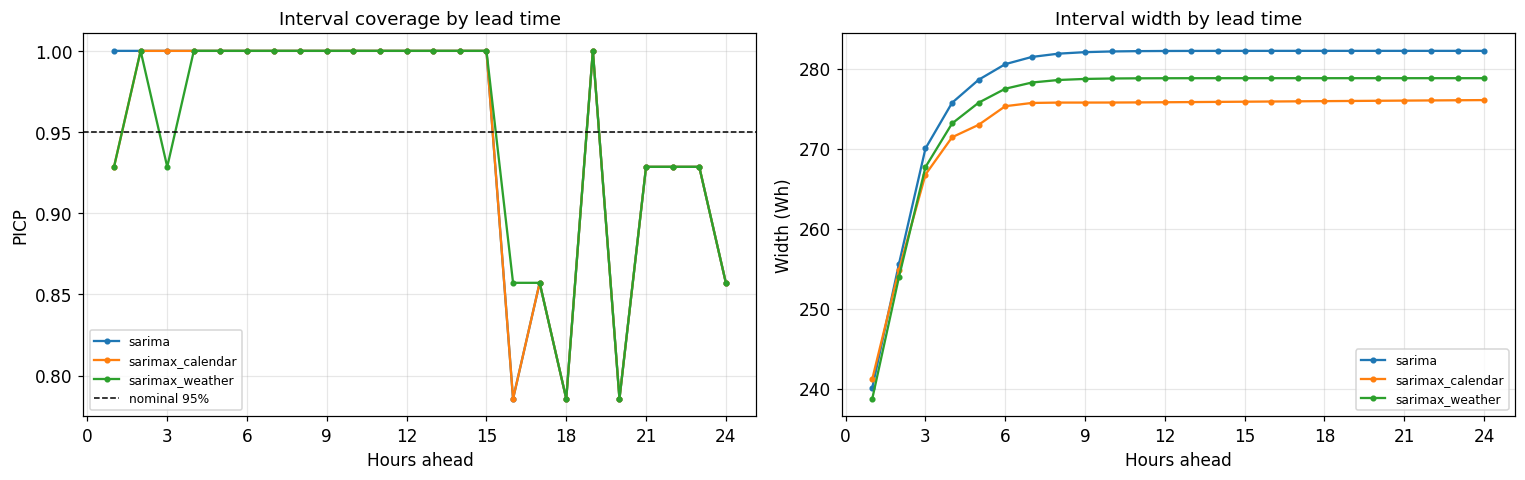

In [15]:
interval_scores = scores[["model", "PICP", "MPIW"]].copy()
interval_scores["nominal"] = 0.95
interval_scores["coverage gap"] = interval_scores["PICP"] - 0.95
interval_scores["width / mean demand"] = (interval_scores["MPIW"] /
                                          series.iloc[-TEST_STEPS:].mean())

print("Interval performance at the nominal 95% level")
print("=" * 76)
print(interval_scores.round(3).to_string(index=False))
interval_scores.to_csv(METRICS_DIR / "part4_intervals.csv", index=False)

coverage_by_step = (forecasts.assign(
    inside=(forecasts["actual"] >= forecasts["lower"]) &
           (forecasts["actual"] <= forecasts["upper"]))
    .groupby(["model", "step"])["inside"].mean().unstack(0))

width_by_step = (forecasts.assign(width=forecasts["upper"] - forecasts["lower"])
                 .groupby(["model", "step"])["width"].mean().unstack(0))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for model in coverage_by_step.columns:
    axes[0].plot(coverage_by_step.index, coverage_by_step[model],
                 marker="o", markersize=3, label=model)
    axes[1].plot(width_by_step.index, width_by_step[model],
                 marker="o", markersize=3, label=model)

axes[0].axhline(0.95, color="black", linestyle="--", linewidth=1.0,
                label="nominal 95%")
axes[0].set(title="Interval coverage by lead time", xlabel="Hours ahead",
            ylabel="PICP", xticks=range(0, 25, 3))
axes[0].legend(fontsize=8)
axes[1].set(title="Interval width by lead time", xlabel="Hours ahead",
            ylabel="Width (Wh)", xticks=range(0, 25, 3))
axes[1].legend(fontsize=8)

fig.tight_layout()
fig.savefig(FIGURE_DIR / "15_interval_performance.png")
plt.show()


Coverage is 95.2% against a nominal 95% for the plain SARIMA model — almost
exact in aggregate despite strongly non-normal residuals. Coverage alone,
however, does not imply sharp uncertainty estimates.

The mean 95% interval width for SARIMA is **278.3 Wh**, about 2.77 times mean
test-period demand. The exogenous variants are slightly narrower rather than
wider: **275.2 Wh** for SARIMAX weather and **272.8 Wh** for SARIMAX calendar,
with coverage of 94.9% for both. This is why interval coverage and interval
width should be considered together: the models are approximately calibrated,
but their uncertainty bands remain broad because appliance-demand spikes are
difficult to predict.

## 8. Forecast plots


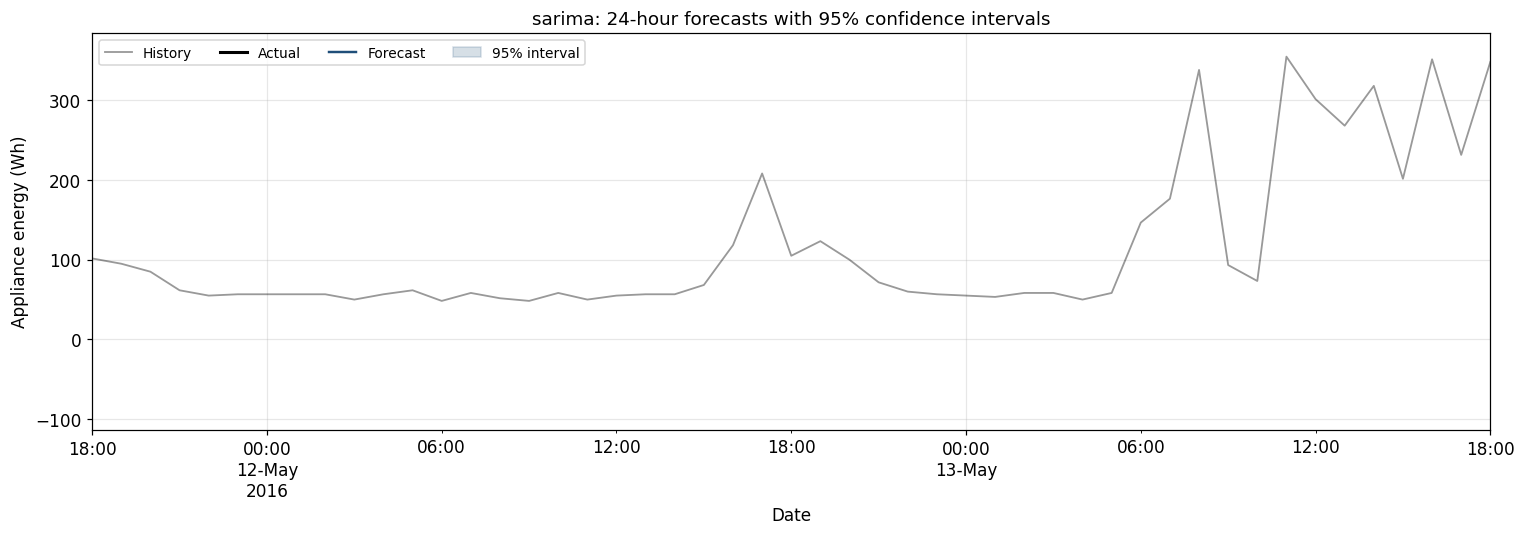

In [16]:
def plot_forecast_with_intervals(frame, model="sarima", n_origins=5):
    """Forecast, actuals and 95% interval across the first few origins."""
    subset = frame[(frame["model"] == model) &
                   (frame["origin_id"] <= n_origins)].sort_values("timestamp")

    fig, ax = plt.subplots(figsize=(14, 5))

    context_start = subset["timestamp"].min() - pd.Timedelta(days=2)
    series.loc[context_start:subset["timestamp"].min()].plot(
        ax=ax, color="black", alpha=0.4, linewidth=1.2, label="History")

    ax.plot(subset["timestamp"], subset["actual"], color="black",
            linewidth=2.0, label="Actual")
    ax.plot(subset["timestamp"], subset["prediction"], color=PRIMARY,
            linewidth=1.6, label="Forecast")
    ax.fill_between(subset["timestamp"], subset["lower"], subset["upper"],
                    color=PRIMARY, alpha=0.18, label="95% interval")

    for origin_id in range(1, n_origins + 1):
        boundary = subset[subset["origin_id"] == origin_id]["timestamp"].min()
        ax.axvline(boundary, color="grey", linestyle=":", linewidth=0.8)

    ax.set(title=f"{model}: 24-hour forecasts with 95% confidence intervals",
           ylabel="Appliance energy (Wh)", xlabel="Date")
    ax.legend(ncol=4, fontsize=9)

    fig.tight_layout()
    return fig


fig = plot_forecast_with_intervals(forecasts, "sarima", n_origins=5)
fig.savefig(FIGURE_DIR / "16_sarima_forecast_intervals.png")
plt.show()


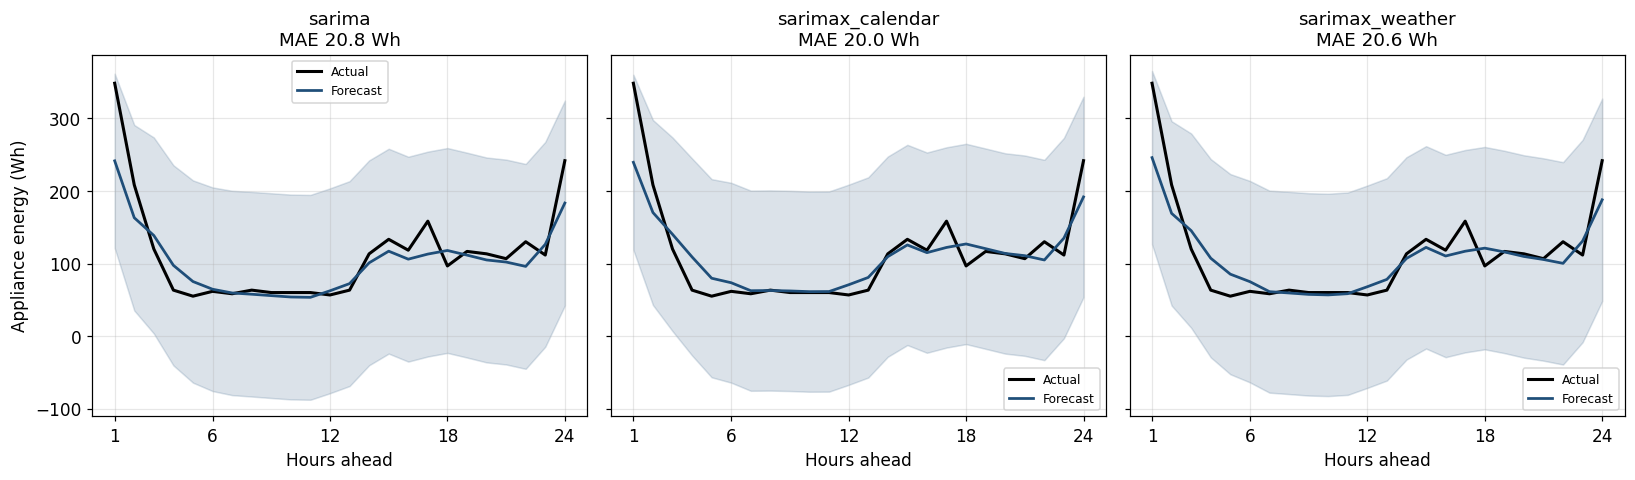

In [17]:
def plot_variant_comparison(frame, origin_id=1):
    """One panel per SARIMAX variant for a single forecast day."""
    models = list(SPECS)
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)

    for ax, model in zip(axes, models):
        subset = frame[(frame["model"] == model) &
                       (frame["origin_id"] == origin_id)]
        ax.plot(subset["step"], subset["actual"], color="black",
                linewidth=2.0, label="Actual")
        ax.plot(subset["step"], subset["prediction"], color=PRIMARY,
                linewidth=1.8, label="Forecast")
        ax.fill_between(subset["step"], subset["lower"], subset["upper"],
                        color=PRIMARY, alpha=0.16)

        error = np.mean(np.abs(subset["actual"] - subset["prediction"]))
        ax.set(title=f"{model}\nMAE {error:.1f} Wh", xlabel="Hours ahead",
               xticks=[1, 6, 12, 18, 24])
        ax.legend(fontsize=8)

    axes[0].set_ylabel("Appliance energy (Wh)")
    fig.tight_layout()
    return fig


fig = plot_variant_comparison(forecasts, origin_id=1)
fig.savefig(FIGURE_DIR / "17_sarimax_variants.png")
plt.show()


## 9. Question 2

> **Does the SARIMAX model improve on the strongest seasonal benchmark?
> Discuss whether daily seasonality, autocorrelation, and exogenous variables
> are adequately captured.**

The evidence is assembled below; the written answer belongs in the report.


In [18]:
comparison = scores[["model", "MAE", "RMSE", "MASE", "Bias", "PICP", "MPIW"]].copy()
comparison = pd.concat([
    comparison,
    pd.DataFrame([{"model": f"{BENCHMARK_NAME} (Part 3)",
                   "MAE": BENCHMARK_MAE, "RMSE": 79.67,
                   "MASE": BENCHMARK_MASE, "Bias": -12.62,
                   "PICP": np.nan, "MPIW": np.nan}])
], ignore_index=True).sort_values("MASE")

print("Evidence for Question 2")
print("=" * 92)
print(comparison.round(3).to_string(index=False))

print("\nSeasonality and autocorrelation captured?")
print(f"  AIC gain from seasonal terms : "
      f"{grid['aic'].min() - seasonal_grid['aic'].min():.0f} points")
print(f"  Ljung-Box p at lag 24        : {ljung.loc[24, 'lb_pvalue']:.3f}")
print(f"  Ljung-Box p at lag 168       : {ljung.loc[168, 'lb_pvalue']:.3f}")
print(f"  Residual ACF at lag 24       : {resid_acf[DAILY_PERIOD]:+.3f}")

print("\nExogenous variables helping?")
for _, row in scores.iterrows():
    print(f"  {row['model']:<20} MAE {row['MAE']:6.2f} Wh   "
          f"MASE {row['MASE']:.3f}")

print("\nSignificance against the strongest benchmark:")
print(dm_results[dm_results["vs"] == BENCHMARK_NAME]
      [["model", "p-value", "conclusion"]].to_string(index=False))


Evidence for Question 2
                         model    MAE   RMSE  MASE    Bias  PICP    MPIW
                        sarima 37.058 64.083 0.695  -3.155 0.952 278.287
               sarimax_weather 38.330 64.244 0.718  -3.317 0.949 275.170
              sarimax_calendar 39.661 63.530 0.743   3.072 0.949 272.842
seasonal_naive_weekly (Part 3) 42.920 79.670 0.804 -12.620   NaN     NaN

Seasonality and autocorrelation captured?
  AIC gain from seasonal terms : 807 points
  Ljung-Box p at lag 24        : 0.675
  Ljung-Box p at lag 168       : 0.142
  Residual ACF at lag 24       : +0.023

Exogenous variables helping?
  sarima               MAE  37.06 Wh   MASE 0.695
  sarimax_weather      MAE  38.33 Wh   MASE 0.718
  sarimax_calendar     MAE  39.66 Wh   MASE 0.743

Significance against the strongest benchmark:
           model  p-value                conclusion
          sarima   0.3401 no significant difference
sarimax_calendar   0.5381 no significant difference
 sarimax_weather   0.45

## 10. Summary of Part 4

- Full 147-model grid over p ∈ [0,6], d ∈ [0,2], q ∈ [0,6] by AIC; **146 of 147 converged**
- AIC comparability across d verified rather than assumed
- Best non-seasonal model: **ARIMA(4,0,6)**, AIC **32944.1**
- Seasonal search over (P,D,Q) ∈ {0,1}³ at s = 24 on the three best converged base orders
- Selected **SARIMA(2,0,6)(0,1,1,24)**, AIC **32137.2**, an **806.9-point** improvement over the best non-seasonal AIC
- Residuals pass Ljung-Box at lags 24, 48 and 168; residuals remain strongly non-normal
- Rolling-origin 24-hour forecasts with 95% intervals, fitted once and state-updated
- Plain SARIMA achieved **MAE 37.06 Wh, RMSE 64.08 Wh, MASE 0.695** — **13.7% lower MAE** than the weekly seasonal-naive benchmark
- The SARIMA-versus-weekly benchmark difference was **not statistically significant** (DM p = 0.340)
- Exogenous weather/calendar variants did **not improve MAE or MASE**; the calendar variant did have a slightly lower RMSE and narrower interval width
- SARIMA 95% interval coverage was **95.2%**, with mean interval width **278.3 Wh**

**Files written**

- `outputs/metrics/part4_grid_nonseasonal.csv`, `part4_grid_seasonal.csv`
- `outputs/metrics/part4_sarimax_scores.csv`, `part4_by_origin.csv`
- `outputs/metrics/part4_ljung_box.csv`, `part4_intervals.csv`
- `outputs/metrics/part4_diebold_mariano.csv`, `part4_model_summary.txt`
- `outputs/forecasts/part4_sarimax_forecasts.csv`
- `outputs/figures/13` to `17`
